# Домашняя работа 5.

## Подготовка.

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


Интересно будет сравнить работу xLSTM и трансформера для одной и той же задачи, а именно предсказание 40 следующих кадров по 80 полученным. Использовать будем тот же [корпус](https://www.csc.kth.se/cvap/actions/) по той же схеме загрузки.

In [2]:
train = np.load('kth_data_train.npz', allow_pickle = True)
X_train, y_train, ids_train, labels_train = train['X'], train['Y'], train['ids'], train['labels']
test = np.load('kth_data_test.npz', allow_pickle = True)
X_test, y_test, ids_train, labels_train = test['X'], test['Y'], test['ids'], test['labels']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((383, 80, 4096), (383, 40, 4096), (216, 80, 4096), (216, 40, 4096))

## Модель.

Для справедливости возьмём по умолчанию все те же параметры, что и были у xLSTM. Даже слоёв столько же, но при этом предсказывать мы будем не по последнему hidden_state, как было в xLSTM, в котором этот вектор впитывает всю необходиму информацию, предсказывать мы будем по $K$ последним кадрам, которые впитали всю информацию и дают модели какое-то понимание о том, что происходило перед теми 40 кадрами, что ей предстоит предсказать.

In [4]:
class VideoTransformer(nn.Module):
  def __init__(self, input_dim = 4096, hidden_dim = 256, T = 80, num_heads = 8, num_layers = 12, K = 5):
    super(VideoTransformer, self).__init__()
    self.input_dim = input_dim
    self.hidden_dim = hidden_dim
    self.T = T
    self.K = K
    self.in_proj = nn.Linear(in_features=input_dim, out_features=hidden_dim)

    self.pos_emb = nn.Embedding(num_embeddings = 80, embedding_dim=hidden_dim)

    self.transformer = nn.TransformerEncoder(nn.TransformerEncoderLayer(
        d_model=hidden_dim,
        nhead = num_heads,
        dim_feedforward = 1024,
        batch_first = True
        ), num_layers= num_layers)

    self.out_proj = nn.Linear(in_features= K * hidden_dim, out_features = T // 2 * input_dim)

    self.attn_weights = []

  def forward(self, x):
    shape = x.size()
    x = self.in_proj(x)
    x += self.pos_emb(torch.arange(shape[1]).to('cuda').unsqueeze(0))

    enc_out = self.transformer(x)
    enc_out_last = enc_out[:, -self.K:, :].view(shape[0], self.K * self.hidden_dim)
    out = self.out_proj(enc_out_last)

    for layer in self.transformer.layers:
      _, attention_weights = layer.self_attn(x, x, x)
      self.attn_weights.append(attention_weights.detach().cpu())

    return out.view(shape[0], self.T // 2, self.input_dim)

## Обучение.

In [5]:
model = VideoTransformer(K = 12).to('cuda')
model.train()
loss = nn.L1Loss()
opt = optim.Adam(model.parameters(), lr = 0.00001)
num_epochs = 80

for epoch in range(num_epochs):
  loss_arr = []
  for i in range(0, X_train.shape[0], 10):
    X_batch = torch.from_numpy(X_train[i : i + 10]).to('cuda')
    y_batch = torch.from_numpy(y_train[i : i + 10]).to('cuda')

    opt.zero_grad()
    pred = model(X_batch)
    dist = loss(pred, y_batch)
    loss_arr.append(dist.item())

    dist.backward()
    opt.step()

  print(f'Epoch : {epoch + 1} / {num_epochs}, Loss: {sum(loss_arr) / len(loss_arr)}')


Epoch : 1 / 80, Loss: 0.43369679152965546
Epoch : 2 / 80, Loss: 0.19900824167789558
Epoch : 3 / 80, Loss: 0.16946092610939956
Epoch : 4 / 80, Loss: 0.14082075540836042
Epoch : 5 / 80, Loss: 0.11664803899251498
Epoch : 6 / 80, Loss: 0.12062110350682186
Epoch : 7 / 80, Loss: 0.11823743887436695
Epoch : 8 / 80, Loss: 0.10226381875765629
Epoch : 9 / 80, Loss: 0.10114773916892517
Epoch : 10 / 80, Loss: 0.10160694175805801
Epoch : 11 / 80, Loss: 0.10339587277326828
Epoch : 12 / 80, Loss: 0.1008386743756441
Epoch : 13 / 80, Loss: 0.09893326958020528
Epoch : 14 / 80, Loss: 0.09923911744203323
Epoch : 15 / 80, Loss: 0.10046638261813384
Epoch : 16 / 80, Loss: 0.10029815729611959
Epoch : 17 / 80, Loss: 0.09642582577772629
Epoch : 18 / 80, Loss: 0.09627879028901076
Epoch : 19 / 80, Loss: 0.09815259965566489
Epoch : 20 / 80, Loss: 0.09862027317285538
Epoch : 21 / 80, Loss: 0.09515245870137826
Epoch : 22 / 80, Loss: 0.09404494345952304
Epoch : 23 / 80, Loss: 0.09499074900761628
Epoch : 24 / 80, Loss

## Валидация.

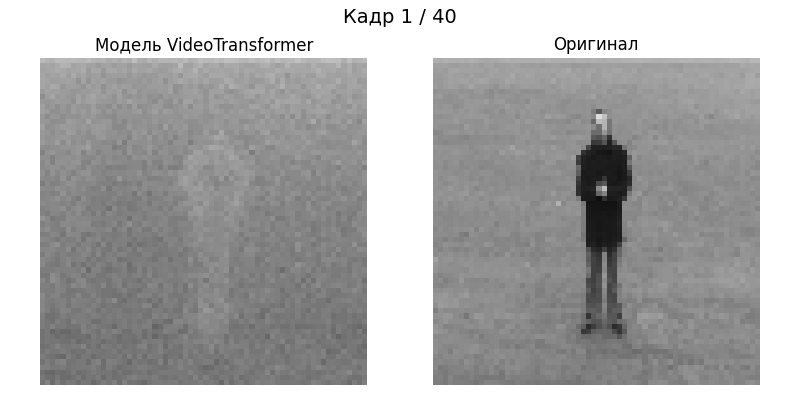

In [7]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display

test_input = torch.from_numpy(X_test[42]).to('cuda').unsqueeze(0)
model.eval()
out_test = model(test_input)
out_video = out_test.view(40, 4096)


pred_frames = out_video.detach().cpu().numpy().reshape(40, 64, 64)
true_frames = y_test[42].reshape(40, 64, 64)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle("Сравнение генерации VideoTransformer и Оригинала", fontsize=14)

ax1.set_title("Модель VideoTransformer")
ax1.axis('off')
im1 = ax1.imshow(pred_frames[0], cmap='gray', vmin=0, vmax=1)

ax2.set_title("Оригинал")
ax2.axis('off')
im2 = ax2.imshow(true_frames[0], cmap='gray', vmin=0, vmax=1)

plt.tight_layout()

def update(frame_idx):
    im1.set_data(pred_frames[frame_idx])
    im2.set_data(true_frames[frame_idx])
    fig.suptitle(f"Кадр {frame_idx + 1} / 40", fontsize=14)
    return [im1, im2]

ani = animation.FuncAnimation(
    fig, update, frames=40, interval=100, blit=False
)

ani.save("vit_comparison.gif", writer="pillow")
plt.close()
display(Image(filename="vit_comparison.gif"))


## Визуализация весов внимания.

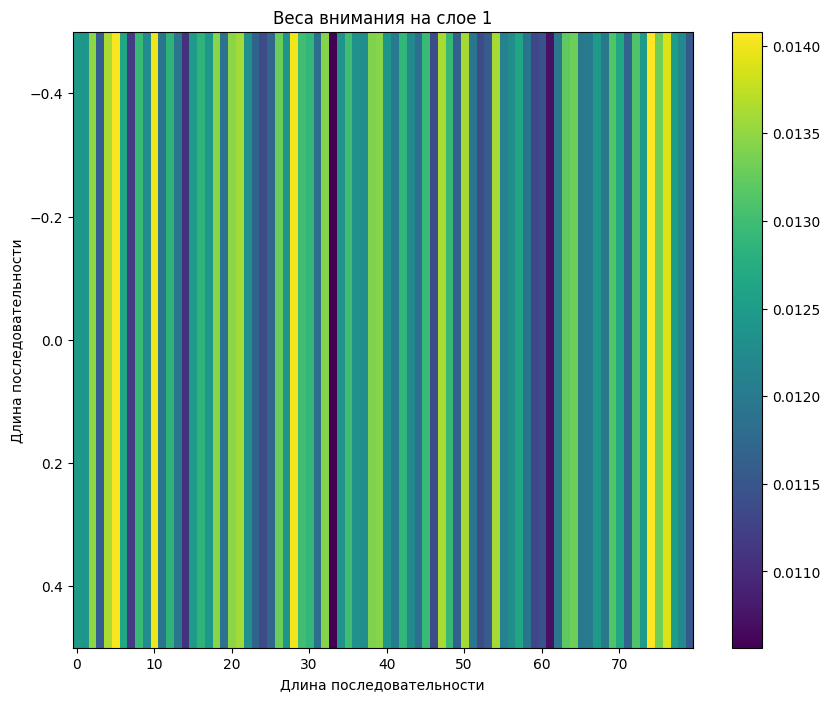

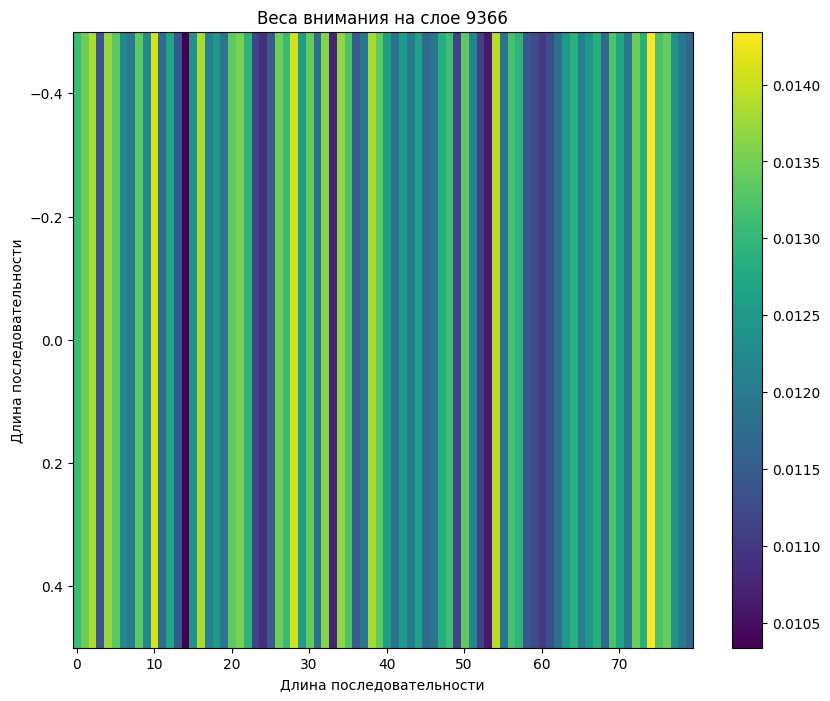

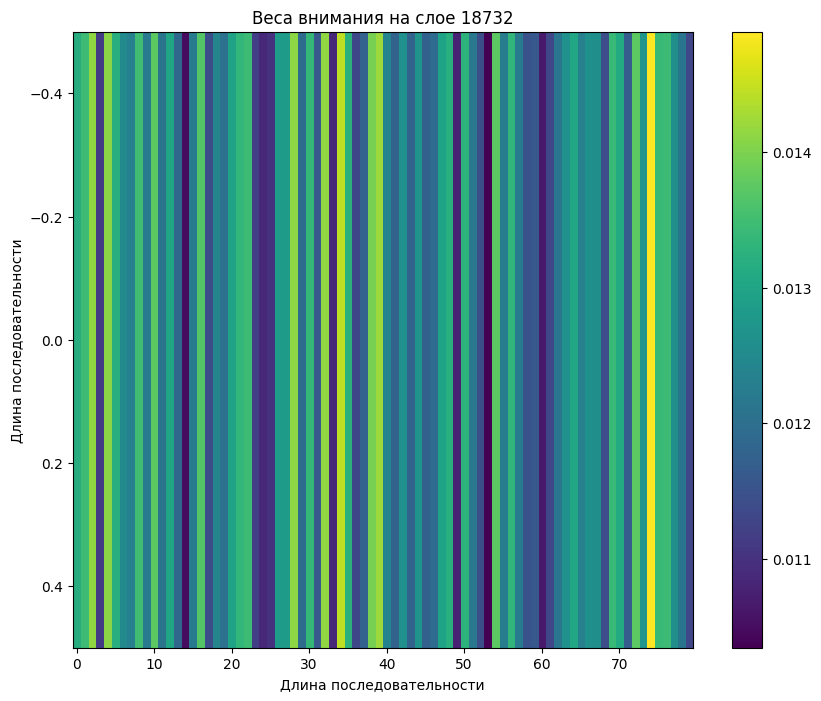

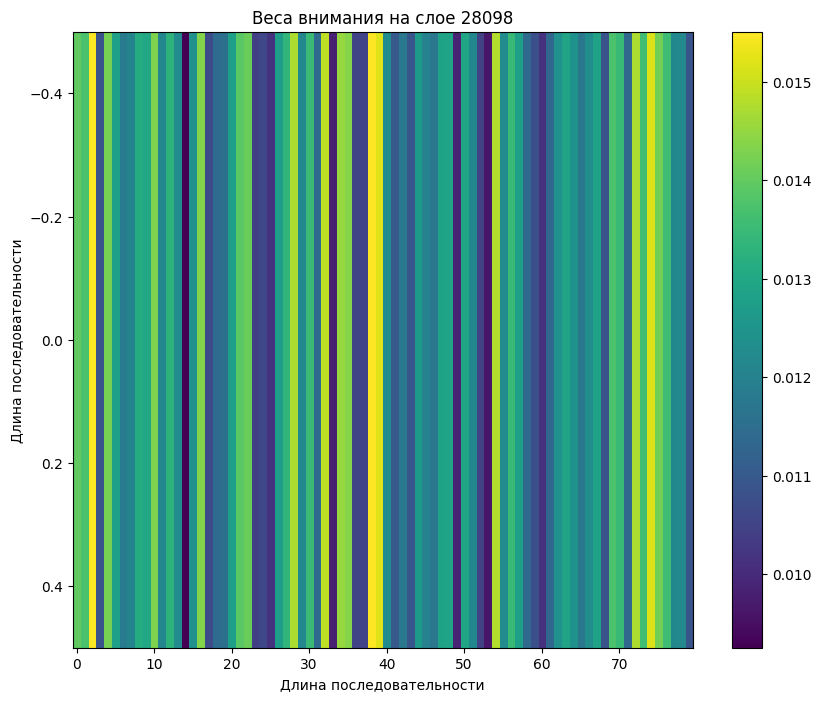

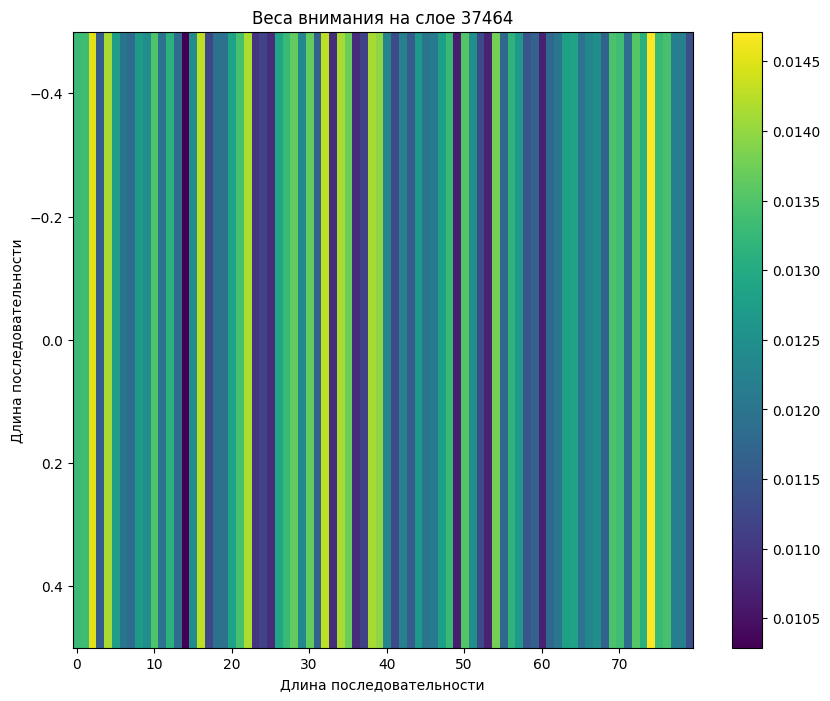

<Figure size 640x480 with 0 Axes>

In [26]:
def plot_attention_weights(weights, layer):
    attention_weights = weights[layer]
    # Если веса внимания имеют больше чем 2 размерности, усредняем по головам
    if len(attention_weights.shape) > 2:
        attention_weights = attention_weights.mean(dim=1).squeeze().detach().numpy() # Усреднение по головам
        if attention_weights.shape[0] != 1 and len(attention_weights.shape) != 1:
          attention_weights = attention_weights[0]

    # Проверяем размерность после усреднения
    if attention_weights.ndim == 1:
        attention_weights = attention_weights[None, :] # Преобразование в двумерный массив (1, seq_len)

    plt.figure(figsize = (10, 8))
    plt.imshow(attention_weights, cmap = 'viridis', aspect = 'auto')
    plt.colorbar()
    plt.title(f"Веса внимания на слое {layer + 1}")
    plt.xlabel("Длина последовательности")
    plt.ylabel("Длина последовательности")
    plt.show()

num_plots = 5
layers_to_plot = np.linspace(0, len(model.attn_weights) - 1, num_plots, dtype = int)

# Визуализация выбранных слоев
for i in layers_to_plot:
    plot_attention_weights(model.attn_weights, i)

plt.tight_layout()
plt.show()

Отсюда видно, как внимание распределяется по мере обучения модели. На первом измерении модель ещё не обучилась извлекать нужную информацию, поэтому внимание распределенно максимально хаотично. Затем по мере обучения модель начинает перебирать, какие именно кадры содержат наибольшую информацию, поэтому жёлтые полоски перескакивают с кадра на кадр. В какой-то момент модель подобрала наиболее информативные кадры, но при этом ещё подбирает какие-то другие, продолжая распределять внимание. К концу обучения модель уже понимает, какие кадры содержат наибольшую информацию, а какие - нет.

## Выводы:
- **Тот же театр теней**. При `MSELoss` модель аналогично xLSTM делает нечто подобное театру теней, пытаясь вобрать в себя всевозможные паттерны движения, получая какое-то среднее движение. Однако и при `L1Loss` ситуация абсолютно аналогична: модель предсказывает шум, очертание человека и фон, не предсказывая действия как таковые.
- **Вычислительная разница**. Что логично, xLSTM и должен выигрывать у трансформера на маленьких и средних последовательностях, а так как у нас длина ровно 80, то это именно наш случай. Трансформер показал две существенных проигрыша. Во-первых, xLSTM - рекуррентная сеть, поэтому вся информацяи там сосредоточена в скрытом состоянии последнего блока последнего слоя, поэтому именно его мы проецируем линейным слоем в 40 остальных кадров, что работает относительно неплохо. С трансформером так не прокатило, потому что информации исключительно в последнем кадре банально недостаточно, чтобы сколько-то адекватно получить даже те результаты, что были у xLSTM, поэтому кадров приходится брать больше, а отсюда вторая проблема: бешенная асимптотика. Обучение на одном кадре даже быстрее xLSTM, но вот уже 15 кадров обучения банально не запустится из-за того, что оно моментально забьёт всё VRAM. Максимально впритык вычислительным возможностям колаба предсказывалось на 12 кадрах, но даже так это получилось дольше и с большой ошибкой, чем с xLSTM.
- **Интерпретация данных**. Возможно, не очень утешительные результаты ещё связаны с обучаемым позиционным кодированием, потому что трансформер чувствительны к позиционному кодированию, так как должны понимать связь между токенами. Вполне возможно, что обучаемый эмбеддер как-то неправильно передавал информацию о временной связи наших токенов, так как в нашем случае, каждый токен - это спроцированный в меньшее пространство кадр видео.